In [4]:
import os
from pathlib import Path

import sys
sys.path.append("/home/jupyter/ML_ops/Final_Project/src")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Project-relative paths
PROJECT_ROOT = Path("/home/jupyter/ML_ops")  # adjust if needed
DATA_DIR = PROJECT_ROOT / "Final_Project" / "data"
MODEL_DIR = PROJECT_ROOT / "Final_Project" / "models"
MONITORING_DIR = PROJECT_ROOT / "Final_Project" / "monitoring"

DATA_DIR, MODEL_DIR, MONITORING_DIR

(PosixPath('/home/jupyter/ML_ops/Final_Project/data'),
 PosixPath('/home/jupyter/ML_ops/Final_Project/models'),
 PosixPath('/home/jupyter/ML_ops/Final_Project/monitoring'))

In [5]:
# Load train/test sets
X_train = pd.read_parquet(DATA_DIR / "X_train.parquet")
X_test = pd.read_parquet(DATA_DIR / "X_test.parquet")
y_train = pd.read_parquet(DATA_DIR / "y_train.parquet")["Price"]
y_test = pd.read_parquet(DATA_DIR / "y_test.parquet")["Price"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train.head()

X_train: (2000, 8)
X_test: (500, 8)
y_train: (2000,)
y_test: (500,)


,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Model
2055,Mercedes,2005,3.4,Electric,Automatic,73401,New,C-Class
1961,BMW,2004,1.6,Diesel,Manual,252234,New,5 Series
1864,Tesla,2002,5.8,Diesel,Manual,89882,Like New,Model X
2326,Mercedes,2000,4.6,Diesel,Manual,275333,New,GLC
461,Honda,2010,3.2,Diesel,Manual,41190,Like New,CR-V


In [6]:
# Load the final trained model (wrapper: PreprocessAndAutoML)
model_path = MODEL_DIR / "model.pkl"
model = joblib.load(model_path)

type(model), model.__dict__.keys()

(models.wrapper.PreprocessAndAutoML, dict_keys(['preprocessor', 'automl']))

In [7]:
model = joblib.load(MODEL_DIR / "model.pkl")
model.preprocessor
model.automl

AutoML(append_log=False, auto_augment=True, custom_hp={},
       cv_score_agg_func=None, early_stop=False, ensemble=False,
       estimator_list='auto', eval_method='auto', fit_kwargs_by_estimator={},
       force_cancel=False, free_mem_ratio=0, hpo_method='auto',
       keep_search_state=False, learner_selector='sample', log_file_name='',
       log_training_metric=False, log_type='better', max_iter=None,
       mem_thres=4294967296, metric='auto', metric_constraints=[],
       min_sample_size=10000, mlflow_logging=True, model_history=False,
       n_concurrent_trials=1, n_jobs=-1, n_splits=5, pred_time_limit=inf,
       preserve_checkpoint=True, retrain_full=True, ...)

In [13]:
os.getcwd()

'/home/jupyter/ML_ops/Final_Project/notebooks'

In [14]:
X_train = pd.read_parquet("../data/X_train.parquet")
y_train = pd.read_parquet("../data/y_train.parquet")["Price"]
X_test = pd.read_parquet("../data/X_test.parquet")
y_test = pd.read_parquet("../data/y_test.parquet")["Price"]

In [15]:
# Predict on full test set
y_pred = model.predict(X_test)

len(y_pred), len(y_test)

(500, 500)

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE (offline, direct model): {rmse:,.2f}")
print(f"Test MAE:                         {mae:,.2f}")
print(f"Test R^2:                         {r2:,.4f}")

Test RMSE (offline, direct model): 27,677.23
Test MAE:                         23,865.78
Test R^2:                         -0.0112


In [17]:
results_df = (
    pd.DataFrame({
        "actual_price": y_test.values,
        "predicted_price": y_pred
    })
    .assign(
        error=lambda df: df["predicted_price"] - df["actual_price"],
        abs_error=lambda df: df["error"].abs()
    )
)

results_df.head(10)

,actual_price,predicted_price,error,abs_error
0,17494.90,52713.036426,35218.136426,35218.136426
1,75919.94,52128.758977,-23791.181023,23791.181023
2,87474.10,53039.603854,-34434.496146,34434.496146
3,13522.58,51802.191549,38279.611549,38279.611549
4,77070.57,51388.969492,-25681.600508,25681.600508
5,40085.49,51316.820251,11231.330251,11231.330251
6,47196.40,52128.758977,4932.358977,4932.358977
7,58558.94,52128.758977,-6430.181023,6430.181023
8,23029.74,51316.820251,28287.080251,28287.080251
9,32351.06,50577.030765,18225.970765,18225.970765


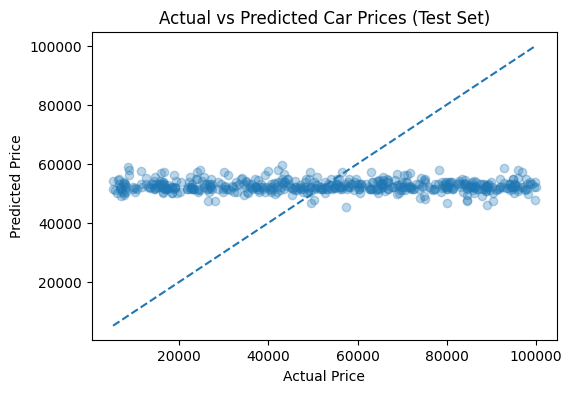

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(results_df["actual_price"], results_df["predicted_price"], alpha=0.3)
mn, mx = results_df["actual_price"].min(), results_df["actual_price"].max()
plt.plot([mn, mx], [mn, mx], linestyle="--")  # 45-degree line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices (Test Set)")
plt.show()

In [19]:
log_path = "../monitoring/predictions_log.csv"

if os.path.exists(log_path):
    log_df = pd.read_csv(log_path)
    print("Monitoring log shape:", log_df.shape)
    display(log_df.head())
else:
    print("No monitoring log found at:", log_path)

Monitoring log shape: (400, 11)


,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Model,prediction,timestamp,request_id
0,Honda,2010,3.0,Diesel,Manual,211864,Like New,Fit,52713.036426,2025-11-22T22:01:30.009061,73c2d6bf-0b40-43a2-ab51-0e00b44e5e41
1,Tesla,2020,4.4,Hybrid,Manual,18781,Like New,Model 3,52128.758977,2025-11-22T22:01:30.009061,73c2d6bf-0b40-43a2-ab51-0e00b44e5e41
2,Toyota,2013,4.3,Diesel,Manual,55547,Like New,RAV4,53039.603854,2025-11-22T22:01:30.009061,73c2d6bf-0b40-43a2-ab51-0e00b44e5e41
3,Toyota,2006,3.0,Hybrid,Automatic,196914,Used,Camry,51802.191549,2025-11-22T22:01:30.009061,73c2d6bf-0b40-43a2-ab51-0e00b44e5e41
4,BMW,2016,5.5,Petrol,Automatic,67764,Like New,5 Series,51388.969492,2025-11-22T22:01:30.009061,73c2d6bf-0b40-43a2-ab51-0e00b44e5e41


In [20]:
if os.path.exists(log_path):
    print("Columns:", log_df.columns.tolist())
    print("\nPrediction summary:")
    print(log_df["prediction"].describe())

    print("\nUnique request_ids:", log_df["request_id"].nunique())

Columns: ['Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage', 'Condition', 'Model', 'prediction', 'timestamp', 'request_id']

Prediction summary:
count      400.000000
mean     52423.844172
std       1796.840025
min      45305.128280
25%      51388.969492
50%      52227.665128
75%      53252.813142
max      58713.122389
Name: prediction, dtype: float64

Unique request_ids: 2
